In [1]:
import numpy as np # loading data
import torch
from torch.utils.data import DataLoader,TensorDataset # Tensor dataset and construct dataloader
import torch.optim as optim # Optimization function
import torch.nn as nn # Call layers and construct model
from torch.optim.lr_scheduler import ReduceLROnPlateau # Adjust learning rate during training
# from torchmetrics.functional import precision_recall
from sklearn import metrics # Model performance metrics
import torchvision.models as models # Import pretrained model
from torchvision.models import ResNet18_Weights
import pickle
import pandas as pd

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print(device)

cuda


In [3]:
# Hyperparameters
batch_size = 64
num_epochs = 30
learning_rate = 0.0001 # Learning rate reduced to ensure stability

In [4]:
# # Hyperparameters
# batch_size = 8 # Reducing batch size reduces the amount of data processed at once, preventing memory issues.
# num_epochs = 20
# learning_rate = 0.01 # Initial learning rate

# Data

In [5]:
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/data_oversample_usingViT.pkl', 'rb') as file:
    loaded_data = pickle.load(file)

# Access the loaded variables
X_train = loaded_data['var1']
X_val = loaded_data['var2']
X_test = loaded_data['var3']
y_train = loaded_data['var4']
y_val = loaded_data['var5']
y_test = loaded_data['var6']

In [6]:
import numpy as np

# Check the unique labels in the dataset
print("Train Labels:", np.unique(y_train))
print("Validation Labels:", np.unique(y_val))
print("Test Labels:", np.unique(y_test))

Train Labels: [0 1 2]
Validation Labels: [0 1 2]
Test Labels: [0 1 2]


In [7]:
# Tensor and convert type to float for inputs and long for labels
train_dataset = TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.Tensor(X_test), torch.LongTensor(y_test))

In [8]:
# # Tensor and convert type to float
# train_dataset = TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train))
# val_dataset = TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val))
# test_dataset = TensorDataset(torch.Tensor(X_test), torch.Tensor(y_test))

In [9]:
# Dataloader
dataloader = {
    "train": DataLoader(dataset=train_dataset,  
                        batch_size=batch_size,  
                        shuffle=True,  
                        num_workers=0,  # To speed up data loading
                        drop_last=False),
    
    "val": DataLoader(dataset=val_dataset,  
                      batch_size=batch_size,  
                      shuffle=False,  
                      num_workers=0,  
                      drop_last=False),
    
    "test": DataLoader(dataset=test_dataset,  
                       batch_size=batch_size,  
                       shuffle=False,  # No need to shuffle test data for consistency across runs
                       num_workers=0,  
                       drop_last=False)
}

In [10]:
# # Dataloader
# dataloader = {"train": DataLoader(dataset=train_dataset,  # torch TensorDataset format
#                                   batch_size=batch_size,  # mini batch size
#                                   shuffle=True,
#                                   num_workers=int(1),
#                                   drop_last=False),
#               "val": DataLoader(dataset=val_dataset,
#                                 batch_size=batch_size,
#                                 shuffle=True,
#                                 num_workers=int(1),
#                                 drop_last=False),
#              "test": DataLoader(dataset=test_dataset,
#                                 batch_size=batch_size,
#                                 shuffle=True,
#                                 num_workers=int(1),
#                                 drop_last=False)}

# Model Construction

In [11]:
# Load a pre-trained ResNet-18 model using weights
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Replace the last fully connected layer for three-class classification
num_classes = 3  # Change from 2 to 3 for three classes

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, num_classes)  # Updated output layer for 3 classes
) 
# Do NOT apply nn.Softmax(dim=1) here, as CrossEntropyLoss includes it implicitly

In [12]:
# # Load a pre-trained ResNet-18 model using weights
# model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# # Replace the last fully connected layer
# num_classes = 2  # Example: number of output classes for your task
# # model.fc = nn.Linear(model.fc.in_features, num_classes)
# model.fc = nn.Sequential(
#     nn.Linear(model.fc.in_features, num_classes)
#     ) #nn.Softmax(dim=1)

# Model Training

In [17]:
%%time
### Model
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

### Training & Validation
print('Training Model ...')
for epoch in range(num_epochs):
    print('Epoch', epoch + 1)
    
    # Training phase
    batch_loss = 0.0
    batch_acc = 0.0
    batch_precision = 0.0
    batch_recall = 0.0
    model.train()
    
    for i, (samples, labels) in enumerate(dataloader["train"]):  # gives batch data
        samples = samples.to(device)  # Move data to GPU
        labels = labels.to(device).long()  # Convert labels to long type for CE Loss
        optimizer.zero_grad()  # Clear the gradients
        
        # Forward pass
        outputs = model(samples)  # Output shape: [batch_size, num_classes]
        pred_labels = torch.argmax(outputs, dim=1)  # Get class with highest probability
        
        loss = criterion(outputs, labels)  # Calculate the loss
        
        # Backward and update
        loss.backward()  # Calculate the gradients
        optimizer.step()  # Update the weights
        
        # Sum training loss and accuracy
        batch_loss += loss.item() / len(labels)
        batch_acc += torch.sum(pred_labels == labels).item() / len(labels)

        # Move labels and predictions to CPU for sklearn metrics
        labels_cpu = labels.cpu().numpy()
        preds_cpu = pred_labels.cpu().numpy()
        
        batch_precision += metrics.precision_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
        batch_recall += metrics.recall_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
    
    # Calculate training loss and accuracy
    train_loss = batch_loss / len(dataloader["train"])
    train_acc = batch_acc / len(dataloader["train"])
    train_precision = batch_precision / len(dataloader["train"])
    train_recall = batch_recall / len(dataloader["train"])
    
    # Validation phase
    batch_loss = 0.0
    batch_acc = 0.0
    model.eval()
    
    for j, (samples, labels) in enumerate(dataloader["val"]):
        samples = samples.to(device)
        labels = labels.to(device).long()
        
        # Only forward pass
        outputs = model(samples)  # Output shape: [batch_size, num_classes]
        pred_labels = torch.argmax(outputs, dim=1)
        
        loss = criterion(outputs, labels)  # Calculate the loss
        
        # Sum validation loss and accuracy
        batch_loss += loss.item() / len(labels)
        batch_acc += torch.sum(pred_labels == labels).item() / len(labels)
    
    # Calculate validation loss and accuracy
    val_loss = batch_loss / len(dataloader['val'])
    val_acc = batch_acc / len(dataloader['val'])
    
    # Print each epoch's training and validation metrics
    nl = '\n'  # New line
    print(f'Epoch [{epoch+1}/{num_epochs}]: {nl} Train, Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}, '
          f'Precision: {train_precision:.4f}, Recall: {train_recall:.4f} {nl} '
          f'Valid, Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f} {nl} '
          f'Learning Rate: {optimizer.param_groups[0]["lr"]}')
    
    # Adjust learning rate based on training loss
    scheduler.step(train_loss)

print('Finished Training')


Training Model ...
Epoch 1
Epoch [1/30]: 
 Train, Loss: 0.0130, Accuracy: 0.6473, Precision: 0.6522, Recall: 0.6485 
 Valid, Loss: 0.0101, Accuracy: 0.8492 
 Learning Rate: 0.0001
Epoch 2
Epoch [2/30]: 
 Train, Loss: 0.0071, Accuracy: 0.8715, Precision: 0.8705, Recall: 0.8729 
 Valid, Loss: 0.0072, Accuracy: 0.8697 
 Learning Rate: 0.0001
Epoch 3
Epoch [3/30]: 
 Train, Loss: 0.0054, Accuracy: 0.8827, Precision: 0.8803, Recall: 0.8848 
 Valid, Loss: 0.0061, Accuracy: 0.8822 
 Learning Rate: 0.0001
Epoch 4
Epoch [4/30]: 
 Train, Loss: 0.0046, Accuracy: 0.8995, Precision: 0.8971, Recall: 0.9025 
 Valid, Loss: 0.0053, Accuracy: 0.8918 
 Learning Rate: 0.0001
Epoch 5
Epoch [5/30]: 
 Train, Loss: 0.0038, Accuracy: 0.9192, Precision: 0.9179, Recall: 0.9210 
 Valid, Loss: 0.0048, Accuracy: 0.9136 
 Learning Rate: 0.0001
Epoch 6
Epoch [6/30]: 
 Train, Loss: 0.0034, Accuracy: 0.9357, Precision: 0.9347, Recall: 0.9390 
 Valid, Loss: 0.0046, Accuracy: 0.9168 
 Learning Rate: 0.0001
Epoch 7
Epoch [

In [14]:
# %%time
# ### Model
# model = model.to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr = learning_rate, momentum=0.9)
# # optimizer = optim.Adam(model.parameters(), lr = learning_rate)
# scheduler = ReduceLROnPlateau(optimizer, factor = 0.1, patience = 5)

# ### Training & Validation
# print('Training Model ...')
# for epoch in range(num_epochs):
#     print('Epoch', epoch+1)
    
#     # Training phase
#     batch_loss = 0.0
#     batch_acc = 0.0
#     batch_precision = 0.0
#     batch_recall = 0.0
#     model.train()
#     for i, (samples, labels) in enumerate(dataloader["train"]): # gives batch data
#         samples = samples.to(device) # Move data to GPU
#         labels = labels.to(device) # Should be [batch_size]
#         optimizer.zero_grad() # Clear the gradients
#         # Forward pass
#         outputs = model(samples) # Should be [batch_size, num_classes]
#         pred_labels = torch.argmax(outputs, dim=1)
#         pred_probs = outputs[:, 1]
#         labels = labels.long()
#         loss = criterion(outputs, labels) # Calculate the loss
#         # Backward and update
#         loss.backward() # Calculate the gradients
#         optimizer.step() # Update the weights
#         # Sum training loss and accuracy
#         batch_loss += loss.item()/len(labels)
#         batch_acc += torch.sum(pred_labels == labels)/len(labels)
#         labels_cpu = labels.cpu(); preds_cpu = pred_labels.cpu()
#         batch_precision += metrics.precision_score(labels_cpu, preds_cpu, zero_division = 0.0)
#         batch_recall += metrics.recall_score(labels_cpu, preds_cpu, zero_division = 0.0)
    
#     # Calculate training loss and accuracy
#     train_loss = batch_loss / len(dataloader["train"])
#     train_acc = batch_acc.double() / len(dataloader["train"])
#     train_precision = batch_precision / len(dataloader["train"])
#     train_recall = batch_recall / len(dataloader["train"])
    
#     # Validation phase
#     batch_loss = 0.0
#     batch_acc = 0.0
#     model.eval()
#     for j, (samples, labels) in enumerate(dataloader["val"]):
#         samples = samples.to(device) # Move data to GPU
#         labels = labels.to(device)
#         # Only forward pass
#         outputs = model(samples) # Should be [batch_size, num_classes]
#         pred_labels = torch.argmax(outputs, dim=1)
#         pred_probs = outputs[:, 1]
#         labels = labels.long()
#         loss = criterion(outputs, labels) # Calculate the loss
#         # Sum validation loss and accuracy
#         batch_loss += loss.item()/len(labels)
#         batch_acc += torch.sum(pred_labels == labels)/len(labels)    
#     # Calculate validation loss and accuracy
#     val_loss = batch_loss / len(dataloader['val'])
#     val_acc = batch_acc.double() / len(dataloader['val'])
    
#     # Print each epoch's training and validation metrics
#     nl = '\n' # new line
#     print(f'Epoch [{epoch+1}/{num_epochs}]: {nl} Train, Loss: {\
#     train_loss:.4f}, Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {\
#     train_recall:.4f} {nl} Valid, Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f} {nl} Learning Rate: {\
#     optimizer.param_groups[0]['lr']}')
    
#     # scheduler.step is called after every epoch, Lr is adjusted based on train_loss
#     scheduler.step(train_loss)

# print('Finished Training')

# Trained Model Test

In [21]:
model.eval()  # Testing mode
batch_acc = 0.0
batch_precision = 0.0
batch_recall = 0.0
prob_all = []
true_labels = []
pred_all = []

for k, (samples, labels) in enumerate(dataloader["test"]):
    samples = samples.to(device)  # Move data to GPU
    labels = labels.to(device).long()  # Convert labels to long for CE Loss
    outputs = model(samples)  # Forward pass
    
    # Apply Softmax to get class probabilities
    softmax_outputs = nn.functional.softmax(outputs, dim=1)
    prob_all.extend(softmax_outputs.cpu().detach().numpy())  # Store entire probability vector
    
    # Get the predicted class (argmax over the softmax output)
    pred_labels = torch.argmax(softmax_outputs, dim=1)

    # Store true labels and predicted labels for evaluation
    true_labels = np.append(true_labels, labels.cpu().detach().numpy())
    pred_all.extend(pred_labels.cpu().detach().numpy())
    
    # Sum batch Accuracy, Precision, and Recall
    batch_acc += torch.sum(pred_labels == labels).item() / len(labels)
    labels_cpu = labels.cpu().numpy()
    preds_cpu = pred_labels.cpu().numpy()
    
    batch_precision += metrics.precision_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
    batch_recall += metrics.recall_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)

# Calculate testing performance metrics
acc = batch_acc / len(dataloader["test"])
precision = batch_precision / len(dataloader["test"])
recall = batch_recall / len(dataloader["test"])

# Print testing performance metrics
nl = '\n'  # New line
print(f'Testing: {nl} Accuracy = {acc:.4f} {nl} Precision = {precision:.4f} {nl} Recall = {recall:.4f}')

Testing: 
 Accuracy = 0.9688 
 Precision = 0.7778 
 Recall = 0.7629


# Replicate Running

In [13]:
%%time
times = 10 # number of running times
all_runs = []
for i in range(times):
    # Training & Validation
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)
    print('Training Model ...')
    for epoch in range(num_epochs):
        print('Epoch', epoch + 1)
        batch_loss = 0.0
        batch_acc = 0.0
        batch_precision = 0.0
        batch_recall = 0.0
        model.train()
        for i, (samples, labels) in enumerate(dataloader["train"]):  # gives batch data
            samples = samples.to(device)  # Move data to GPU
            labels = labels.to(device).long()  # Convert labels to long type for CE Loss
            optimizer.zero_grad()  # Clear the gradients
            outputs = model(samples)  # Output shape: [batch_size, num_classes]
            pred_labels = torch.argmax(outputs, dim=1)  # Get class with highest probability
            loss = criterion(outputs, labels)  # Calculate the loss
            loss.backward()  # Calculate the gradients
            optimizer.step()  # Update the weights
            batch_loss += loss.item() / len(labels)
            batch_acc += torch.sum(pred_labels == labels).item() / len(labels)
            labels_cpu = labels.cpu().numpy()
            preds_cpu = pred_labels.cpu().numpy()
            batch_precision += metrics.precision_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
            batch_recall += metrics.recall_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
        train_loss = batch_loss / len(dataloader["train"])
        train_acc = batch_acc / len(dataloader["train"])
        train_precision = batch_precision / len(dataloader["train"])
        train_recall = batch_recall / len(dataloader["train"])
        batch_loss = 0.0
        batch_acc = 0.0
        model.eval()
        for j, (samples, labels) in enumerate(dataloader["val"]):
            samples = samples.to(device)
            labels = labels.to(device).long()
            outputs = model(samples)  # Output shape: [batch_size, num_classes]
            pred_labels = torch.argmax(outputs, dim=1)
            loss = criterion(outputs, labels)  # Calculate the loss
            batch_loss += loss.item() / len(labels)
            batch_acc += torch.sum(pred_labels == labels).item() / len(labels)
        val_loss = batch_loss / len(dataloader['val'])
        val_acc = batch_acc / len(dataloader['val'])
        nl = '\n'  # New line
        print(f'Epoch [{epoch+1}/{num_epochs}]: {nl} Train, Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}, '
              f'Precision: {train_precision:.4f}, Recall: {train_recall:.4f} {nl} '
              f'Valid, Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f} {nl} '
              f'Learning Rate: {optimizer.param_groups[0]["lr"]}')
        scheduler.step(train_loss)
    print('Finished Training')

    # Testing
    model.eval()  # Testing mode
    batch_acc = 0.0
    batch_precision = 0.0
    batch_recall = 0.0
    prob_all = []
    true_labels = []
    pred_all = []
    for k, (samples, labels) in enumerate(dataloader["test"]):
        samples = samples.to(device)  # Move data to GPU
        labels = labels.to(device).long()  # Convert labels to long for CE Loss
        outputs = model(samples)  # Forward pass
        softmax_outputs = nn.functional.softmax(outputs, dim=1)
        prob_all.extend(softmax_outputs.cpu().detach().numpy())  # Store entire probability vector
        pred_labels = torch.argmax(softmax_outputs, dim=1)
        true_labels = np.append(true_labels, labels.cpu().detach().numpy())
        pred_all.extend(pred_labels.cpu().detach().numpy())
        batch_acc += torch.sum(pred_labels == labels).item() / len(labels)
        labels_cpu = labels.cpu().numpy()
        preds_cpu = pred_labels.cpu().numpy()
        batch_precision += metrics.precision_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
        batch_recall += metrics.recall_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
    # Calculate testing performance metrics
    acc = batch_acc / len(dataloader["test"])
    precision = batch_precision / len(dataloader["test"])
    recall = batch_recall / len(dataloader["test"])
    # Print testing performance metrics
    nl = '\n'  # New line
    print(f'Testing: {nl} Accuracy = {acc:.4f} {nl} Precision = {precision:.4f} {nl} Recall = {recall:.4f}')

    # Save prob_all of all runs
    prob_all_2d = np.vstack(prob_all)
    all_runs.append(prob_all_2d)
all_runs_array = np.stack(all_runs, axis=0)

Training Model ...
Epoch 1
Epoch [1/30]: 
 Train, Loss: 0.0110, Accuracy: 0.7809, Precision: 0.7801, Recall: 0.7796 
 Valid, Loss: 0.0090, Accuracy: 0.8791 
 Learning Rate: 0.0001
Epoch 2
Epoch [2/30]: 
 Train, Loss: 0.0064, Accuracy: 0.8739, Precision: 0.8715, Recall: 0.8744 
 Valid, Loss: 0.0069, Accuracy: 0.8822 
 Learning Rate: 0.0001
Epoch 3
Epoch [3/30]: 
 Train, Loss: 0.0049, Accuracy: 0.8887, Precision: 0.8864, Recall: 0.8887 
 Valid, Loss: 0.0059, Accuracy: 0.8869 
 Learning Rate: 0.0001
Epoch 4
Epoch [4/30]: 
 Train, Loss: 0.0041, Accuracy: 0.9068, Precision: 0.9055, Recall: 0.9093 
 Valid, Loss: 0.0053, Accuracy: 0.8978 
 Learning Rate: 0.0001
Epoch 5
Epoch [5/30]: 
 Train, Loss: 0.0035, Accuracy: 0.9222, Precision: 0.9204, Recall: 0.9238 
 Valid, Loss: 0.0049, Accuracy: 0.9009 
 Learning Rate: 0.0001
Epoch 6
Epoch [6/30]: 
 Train, Loss: 0.0030, Accuracy: 0.9383, Precision: 0.9368, Recall: 0.9410 
 Valid, Loss: 0.0045, Accuracy: 0.9105 
 Learning Rate: 0.0001
Epoch 7
Epoch [

In [14]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import auc, roc_curve

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
n_classes = 3

all_auc = []
all_fpr = []
all_tpr = []
for i in range(times):
    prob_all = all_runs_array[i]
    fpr, tpr, roc_auc = dict(), dict(), dict()
    fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), np.array(prob_all).ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], np.array(prob_all)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)
    for i in range(n_classes):
        mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation
    mean_tpr /= n_classes
    fpr["macro"] = fpr_grid
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    all_auc.append(roc_auc)
    all_fpr.append(fpr)
    all_tpr.append(tpr)

In [15]:
# with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/auc_resnet.pkl', 'wb') as f:
#         pickle.dump(all_auc, f)

dt = {
    'var1': all_runs_array,
    'var2': all_auc,
    'var3': all_fpr,
    'var4': all_tpr
}

# Save to file
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/resnet.pkl', 'wb') as file:
    pickle.dump(dt, file)

# Old

In [21]:
true_labels

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [18]:
pred_all

[1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [19]:
import csv
with open('C:/Users/101194208/Desktop/die_casting_ensemble/Result/true_pred_resnet.csv', 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    for item1, item2 in zip(true_labels, pred_all):
        csv_writer.writerow([item1, item2])

In [12]:
model.eval()  # Set to evaluation mode
true_labels = []
pred_labels = []

for samples, labels in dataloader["test"]:
    samples = samples.to(device)
    labels = labels.to(device).long()
    
    # Forward pass
    outputs = model(samples)
    
    # Get predicted class (highest probability)
    pred = torch.argmax(outputs, dim=1)
    
    # Store predictions & true labels batch-wise
    true_labels.extend(labels.cpu().numpy())  # Append entire batch
    pred_labels.extend(pred.cpu().numpy())    # Append entire batch


In [18]:
# model.eval() # Testing mode
# batch_acc = 0.0
# batch_precision = 0.0
# batch_recall = 0.0
# prob_all = []
# true_labels= []
# for k, (samples, labels) in enumerate(dataloader["test"]):
#     samples = samples.to(device) # Move data to GPU
#     labels = labels.to(device)
#     outputs = model(samples)
#     softmax_outputs = nn.functional.softmax(outputs, dim=1)
#     # print(softmax_outputs)
#     pred_labels = torch.argmax(softmax_outputs, dim=1)
#     # print(pred_labels)
#     pred_probs = softmax_outputs[:, 1]
#     prob_all = np.append(prob_all, pred_probs.to('cpu').detach().numpy())
#     true_labels = np.append(true_labels, labels.to('cpu').detach().numpy())
#     # Sum batch Accuracy, Precision, and Recall
#     batch_acc += torch.sum(pred_labels == labels)/len(labels)
#     labels_cpu = labels.cpu(); preds_cpu = pred_labels.cpu()
#     batch_precision += metrics.precision_score(labels_cpu, preds_cpu, zero_division = 0.0)
#     batch_recall += metrics.recall_score(labels_cpu, preds_cpu, zero_division = 0.0)
# # Calculate testing performance metrics
# acc = batch_acc.double() / len(dataloader["test"])
# precision = batch_precision / len(dataloader["test"])
# recall = batch_recall / len(dataloader["test"])

# # Print testing performance metrics
# nl = '\n' # new line
# print(f'Testing: {nl} Accuracy = {acc:.4f} {nl} Precision = {precision:.4f} {nl} Recall = {recall:.4f}')

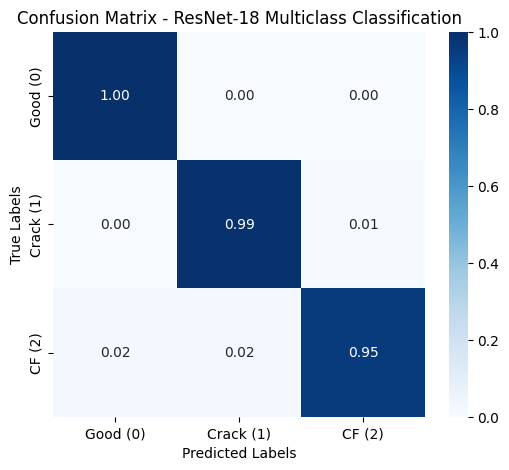

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
conf_matrix = confusion_matrix(true_labels, pred_labels)

# Normalize confusion matrix (optional, for better visualization)
conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Define class labels
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_norm, annot=True, cmap="Blues", fmt=".2f",
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - ResNet-18 Multiclass Classification")
plt.show()


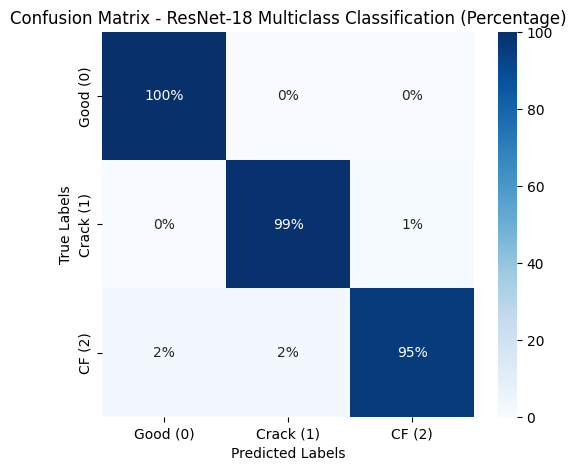

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix
conf_matrix = confusion_matrix(true_labels, pred_labels)

# Normalize confusion matrix (convert to percentages)
conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Define class labels
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']

# Format annotations with % sign
annotations = np.array([["{:.0f}%".format(value) for value in row] for row in conf_matrix_norm])

# Plot confusion matrix with percentage labels
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_norm, annot=annotations, cmap="Blues", fmt="",  # fmt="" to use custom annotations
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - ResNet-18 Multiclass Classification (Percentage)")
plt.show()


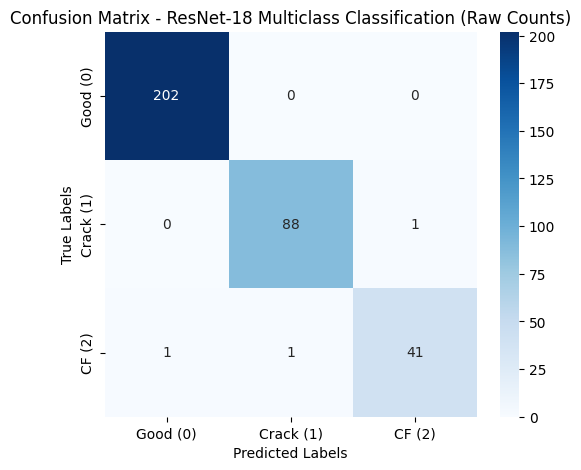

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix (raw counts)
conf_matrix = confusion_matrix(true_labels, pred_labels)

# Define class labels
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']

# Plot confusion matrix with raw counts
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",  # fmt="d" ensures integers
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - ResNet-18 Multiclass Classification (Raw Counts)")
plt.show()


In [22]:
from sklearn.metrics import f1_score

# Compute F1-score for multiclass classification
f1_macro = f1_score(true_labels, pred_labels, average="macro")  # Macro-average (equal weight for all classes)
f1_micro = f1_score(true_labels, pred_labels, average="micro")  # Micro-average (global metric)
f1_weighted = f1_score(true_labels, pred_labels, average="weighted")  # Weighted (accounts for class imbalance)
f1_per_class = f1_score(true_labels, pred_labels, average=None)  # F1-score per class

# Display F1-scores
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Micro): {f1_micro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Print F1-score for each class
for i, score in enumerate(f1_per_class):
    print(f"F1 Score for Class {i}: {score:.4f}")

F1 Score (Macro): 0.9837
F1 Score (Micro): 0.9910
F1 Score (Weighted): 0.9910
F1 Score for Class 0: 0.9975
F1 Score for Class 1: 0.9888
F1 Score for Class 2: 0.9647


In [23]:
model.eval()  # Set model to evaluation mode
prob_all = []  # Ensure prob_all is an empty list to collect values
true_labels = []

for samples, labels in dataloader["test"]:
    samples = samples.to(device)
    labels = labels.to(device).long()

    # Forward pass
    outputs = model(samples)

    # Apply softmax to get class probabilities
    softmax_outputs = torch.nn.functional.softmax(outputs, dim=1)

    # Store true labels and probabilities
    true_labels.extend(labels.cpu().numpy())  
    prob_all.extend(softmax_outputs.cpu().detach().numpy())  # Collect probabilities correctly

# Convert prob_all to a NumPy array
prob_all = np.array(prob_all)

# Print shape to verify
print(f"Shape of prob_all: {prob_all.shape}")  # Should be (num_samples, num_classes)


Shape of prob_all: (334, 3)


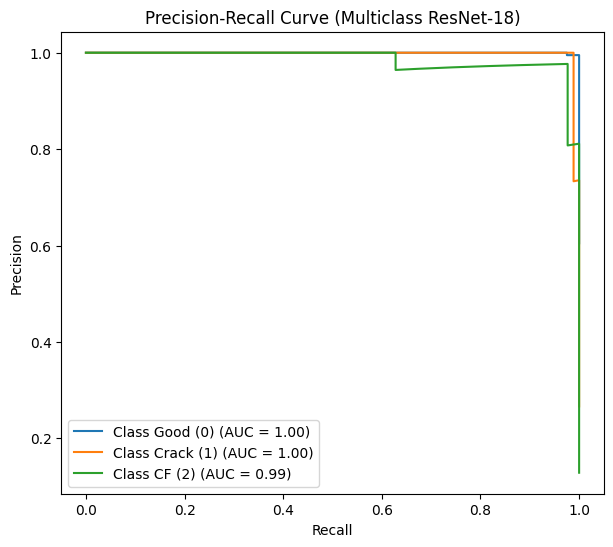

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true labels for one-vs-rest precision-recall calculation
true_labels_bin = label_binarize(true_labels, classes=[0, 1, 2])

# Define class names
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']
plt.figure(figsize=(7, 6))

# Compute and plot PR curve for each class
for i in range(3):  # Loop through each class
    precision, recall, _ = precision_recall_curve(true_labels_bin[:, i], prob_all[:, i])
    pr_auc = auc(recall, precision)  # Compute Precision-Recall AUC
    plt.plot(recall, precision, label=f'Class {class_names[i]} (AUC = {pr_auc:.2f})')

# Plot settings
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Multiclass ResNet-18)')
plt.legend()
# plt.grid()
plt.show()

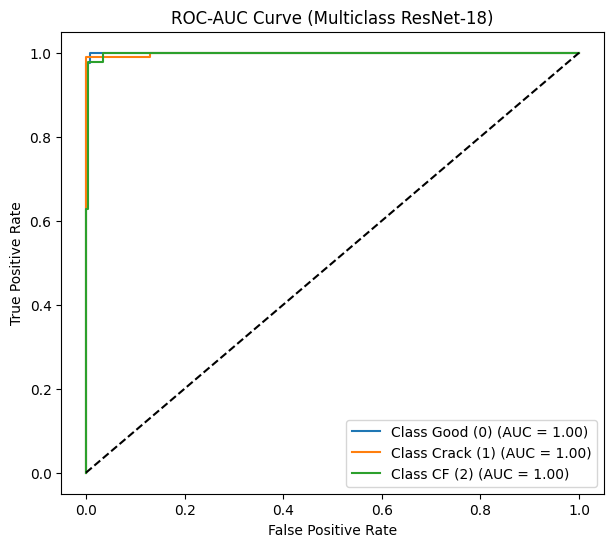

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Ensure prob_all is a NumPy array
prob_all = np.array(prob_all)

# Binarize true labels for one-vs-rest ROC-AUC calculation
true_labels_bin = label_binarize(true_labels, classes=[0, 1, 2])

# Define class names
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']
plt.figure(figsize=(7, 6))

# Compute and plot ROC curve for each class
for i in range(3):  # Loop through each class
    fpr, tpr, _ = roc_curve(true_labels_bin[:, i], prob_all[:, i])
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve (Multiclass ResNet-18)')
plt.legend()
# plt.grid()
plt.show()


In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

# Convert prob_all to a NumPy array
prob_all = np.array(prob_all)

# Binarize true labels for one-vs-rest ROC-AUC calculation
true_labels_bin = label_binarize(true_labels, classes=[0, 1, 2])

# Store FPR, TPR, and Thresholds for each class in a dictionary
roc_data = {}

for i in range(3):  # Loop through each class
    fpr, tpr, thresholds = roc_curve(true_labels_bin[:, i], prob_all[:, i])
    roc_data[f'Class_{i}_fpr'] = fpr
    roc_data[f'Class_{i}_tpr'] = tpr
    roc_data[f'Class_{i}_thresholds'] = thresholds

# Convert dictionary to a format suitable for saving
max_length = max(len(v) for v in roc_data.values())  # Find the longest array length

# Pad shorter arrays with NaN to match the longest length
for key in roc_data:
    roc_data[key] = np.pad(roc_data[key], (0, max_length - len(roc_data[key])), constant_values=np.nan)

# Convert to DataFrame
df_fpr_tpr = pd.DataFrame(roc_data)

# Save to CSV
df_fpr_tpr.to_csv('C:/Users/101160998/Desktop/Research1/Dataset/fpr_tpr_resnet.csv', index=False)

print("Multiclass ROC-AUC data saved successfully!")


Multiclass ROC-AUC data saved successfully!


In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Convert prob_all to a NumPy array
prob_all = np.array(prob_all)

# Binarize true labels for one-vs-rest Precision-Recall calculation
true_labels_bin = label_binarize(true_labels, classes=[0, 1, 2])

# Store Precision-Recall data for each class
pr_data = {}

for i in range(3):  # Loop through each class
    precision, recall, thresholds = precision_recall_curve(true_labels_bin[:, i], prob_all[:, i])
    pr_data[f'Class_{i}_precision'] = precision
    pr_data[f'Class_{i}_recall'] = recall
    pr_data[f'Class_{i}_thresholds'] = thresholds

# Convert to DataFrame for saving
max_length = max(len(v) for v in pr_data.values())  # Find the longest array length

# Pad shorter arrays with NaN to match the longest length
for key in pr_data:
    pr_data[key] = np.pad(pr_data[key], (0, max_length - len(pr_data[key])), constant_values=np.nan)

# Convert to DataFrame
df_pr = pd.DataFrame(pr_data)

# Save to CSV
df_pr.to_csv('C:/Users/101160998/Desktop/Research1/Dataset/pr_resnet.csv', index=False)

print("Multiclass Precision-Recall data saved successfully!")


Multiclass Precision-Recall data saved successfully!


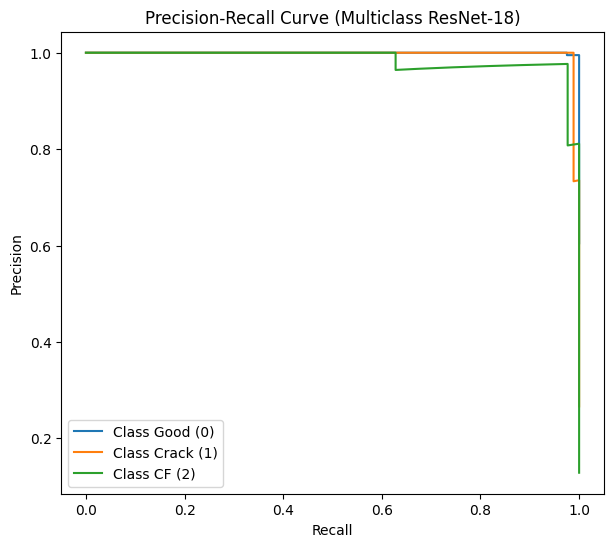

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Binarize true labels for one-vs-rest precision-recall calculation
true_labels_bin = label_binarize(true_labels, classes=[0, 1, 2])

# Define class names
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']
plt.figure(figsize=(7, 6))

# Compute and plot PR curve for each class
for i in range(3):  # Loop through each class
    precision, recall, _ = precision_recall_curve(true_labels_bin[:, i], prob_all[:, i])
    plt.plot(recall, precision, label=f'Class {class_names[i]}')

# Plot settings
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Multiclass ResNet-18)')
plt.legend()
# plt.grid()
plt.show()


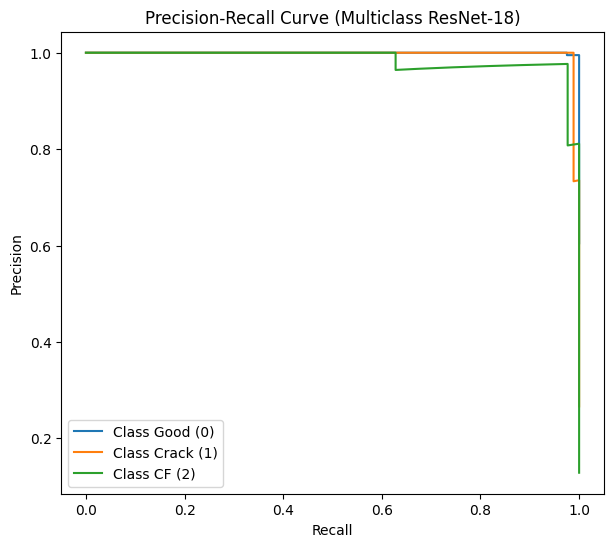

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Convert prob_all to a NumPy array (if it's a list)
prob_all = np.array(prob_all)

# Ensure prob_all is 2D with shape (num_samples, num_classes)
if prob_all.ndim == 1:
    raise ValueError(f"Expected prob_all to have shape (num_samples, num_classes), but got {prob_all.shape}")

# Binarize true labels for one-vs-rest precision-recall calculation
true_labels_bin = label_binarize(true_labels, classes=[0, 1, 2])

# Define class names
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']
plt.figure(figsize=(7, 6))

# Compute and plot PR curve for each class
for i in range(3):  # Loop through each class
    precision, recall, _ = precision_recall_curve(true_labels_bin[:, i], prob_all[:, i])
    plt.plot(recall, precision, label=f'Class {class_names[i]}')

# Plot settings
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Multiclass ResNet-18)')
plt.legend()
# plt.grid()
plt.show()


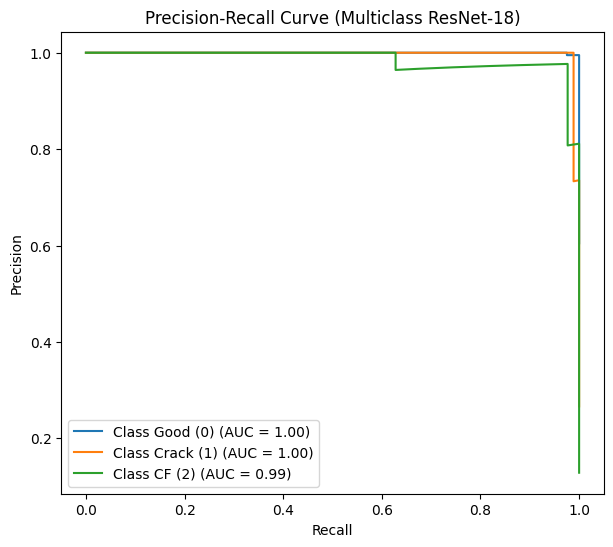

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true labels for one-vs-rest precision-recall calculation
true_labels_bin = label_binarize(true_labels, classes=[0, 1, 2])

# Define class names
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']
plt.figure(figsize=(7, 6))

# Compute and plot PR curve for each class
for i in range(3):  # Loop through each class
    precision, recall, _ = precision_recall_curve(true_labels_bin[:, i], prob_all[:, i])
    pr_auc = auc(recall, precision)  # Compute Precision-Recall AUC
    plt.plot(recall, precision, label=f'Class {class_names[i]} (AUC = {pr_auc:.2f})')

# Plot settings
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Multiclass ResNet-18)')
plt.legend()
# plt.grid()
plt.show()


In [31]:
# fpr, tpr, thresholds = metrics.roc_curve(true_labels, prob_all)
# df_fpr_tpr = {'fpr':fpr, 'tpr':tpr}
# df_fpr_tpr = pd.DataFrame(df_fpr_tpr)
# df_fpr_tpr.to_csv('C:/Users/101160998/Desktop/Research/Data_W/fpr_tpr_resnet.csv', index=False)

In [32]:
# precision, recall, _ = metrics.precision_recall_curve(true_labels, prob_all)
# df_pr = {'precision':precision, 'recall':recall}
# df_pr = pd.DataFrame(df_pr)
# df_pr.to_csv('C:/Users/101160998/Desktop/Research/Data_W/pr_resnet.csv', index=False)